# Tabular Deep Learning: S&P 500 Equity Straddles

TabM applies a shared multilayer perceptron with rank-1 ensemble adapters to the
same option-feature snapshot used by the linear and gradient-boosted models. This
notebook tests whether that parameter-efficient ensemble extracts a stronger
cross-sectional signal for the return-to-expiry target.

**Learning Objectives**:
- Compare small, medium, and large TabM ensembles on the same option features
- Select checkpoints using two purged walk-forward validation folds
- Assess whether model capacity improves return-to-expiry IC
- Generate registered predictions for Chapter 16 strategy simulation

**Book Reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives)

**Prerequisites**: [`02_labels`](02_labels.ipynb) (`dte_calendar`),
[`03_financial_features`](03_financial_features.ipynb) (47 financial features), and
[`04_model_based_features`](04_model_based_features.ipynb) (4 GARCH/SV features)

In [1]:
"""Tabular DL grid search - TabM via walk-forward CV."""

import warnings

import plotly.graph_objects as go
import polars as pl
import torch
import yaml
from ml4t.diagnostic.metrics import cross_sectional_ic

import utils.style as style
from case_studies.utils.registry import (
    build_training_spec,
    compute_fold_metrics_from_predictions,
    load_prediction_sets,
    read_predictions,
    training_hash_from_spec,
)
from case_studies.utils.tabular_dl import run_tabm_cv
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")
COLORS = style.COLORS

In [2]:
CASE_STUDY_ID = "sp500_options"
PRIMARY_LABEL = ""  # Read from setup.yaml if empty
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
BATCH_SIZE = 4096
MAX_FOLDS = 0

In [3]:
# Resolve config from setup.yaml
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

tdl_config = setup.get("modeling", {}).get("tabular_dl", {})
MODELS = tdl_config.get("models", ["tabm"])
DEVICE = tdl_config.get("device", "gpu")

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID}")
print(f"Device: {device_str} | Models: {MODELS}")
print(f"Epochs: {N_EPOCHS} | Batch: {BATCH_SIZE}")

Label from setup.yaml: ret_to_expiry
Case study: sp500_options
Device: cuda | Models: ['tabm']
Epochs: 100 | Batch: 4096


## 1. Load Artifacts

Load the same 52-feature modeling panel used by the linear and GBM notebooks: 47
financial features, 4 model-based features, and `dte_calendar` from the label pipeline.
The comparison therefore isolates model architecture rather than additional inputs.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(f"Label: {label_col} | Date: {date_col} | Entity: {entity_col}")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {str(s['train_start'])[:10]}\u2192{str(s['train_end'])[:10]}  "
        f"val {str(s['val_start'])[:10]}\u2192{str(s['val_end'])[:10]}"
    )

Dataset: 345,912 rows × 52 features
Label: ret_to_expiry | Date: timestamp | Entity: symbol
  Fold 0: train 2018-01-05→2019-11-12  val 2020-01-06→2020-12-31
  Fold 1: train 2017-02-02→2018-11-12  val 2019-01-07→2020-01-03


### Data integrity

In [5]:
dataset_pd = dataset.to_pandas()

label_nans = dataset_pd[label_col].isna().sum()
feat_nan_rate = dataset_pd[feature_names].isna().mean().mean()
n_entities = dataset_pd[entity_col].nunique()

print(f"Entities: {n_entities}")
print(f"Label NaN: {label_nans:,} / {len(dataset_pd):,} ({label_nans / len(dataset_pd):.1%})")
print(f"Feature NaN rate: {feat_nan_rate:.1%}")

Entities: 610
Label NaN: 0 / 345,912 (0.0%)
Feature NaN rate: 1.9%


## 2. Build Grid

The grid scales the shared hidden representation and number of rank-1 ensemble
members: small (64h x 4m), medium (128h x 8m), and large (256h x 16m).

In [6]:
tabdl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "tabular_dl")

# Apply Papermill overrides to configs (test mode: fewer epochs)
for cfg in tabdl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 4096) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE

print(f"Grid: {len(tabdl_configs)} configs × {N_EPOCHS} epochs × {len(splits)} folds")
for cfg in tabdl_configs:
    name = cfg["config_name"]
    params = cfg.get("params", {})
    if name.startswith("tabpfn"):
        print(f"  {name:15s}  max_samples={params.get('max_samples', 2000)}")
    else:
        print(
            f"  {name:15s}  hidden={params['hidden_dim']}  "
            f"members={params['n_members']}  dropout={params['dropout']}"
        )

Grid: 3 configs × 100 epochs × 2 folds
  tabm_s           hidden=64  members=4  dropout=0.1
  tabm_l           hidden=256  members=16  dropout=0.1
  tabm_m           hidden=128  members=8  dropout=0.1


## 3. Run Tabular DL CV

Train each configuration within each fold, fitting imputation and scaling on the
training window only. A reproduce run reads complete registered artifacts without
fitting a model or writing to the registry.

In [7]:
result = run_tabm_cv(
    dataset_pd,
    splits,
    feature_names=feature_names,
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    configs=tabdl_configs,
    n_features=n_features,
    device=device_str,
    save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
    register=True,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
    notebook="08_tabular_dl",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)

  SKIP tabm_s                     (complete (hash=e6a6a1887757), split=validation)
  SKIP tabm_l                     (complete (hash=a8aefd35a0f8), split=validation)
  SKIP tabm_m                     (complete (hash=98245e379370), split=validation)
All configs already registered - rebuilding result from frozen registry.


### Normalize registered checkpoints

A prediction artifact may contain either one checkpoint or a complete checkpoint
path. Normalize both layouts to one observation per configuration and epoch before
computing IC. This keeps cached and freshly trained runs on the same metric contract.

In [8]:
legacy_frames = []
legacy_curves = []
for cfg in tabdl_configs:
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=cfg.get("n_epochs"),
    )
    prediction_sets = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=training_hash_from_spec(spec),
        split=PREDICTION_SPLIT,
    )
    if prediction_sets.height != 1:
        continue
    stored = read_predictions(CASE_STUDY_ID, prediction_sets["prediction_hash"][0])
    if "epoch" not in stored.columns or stored["epoch"].n_unique() <= 1:
        continue
    legacy_frames.append(stored)
    for epoch in sorted(stored["epoch"].unique().to_list()):
        epoch_predictions = stored.filter(pl.col("epoch") == epoch)
        ic = cross_sectional_ic(
            epoch_predictions,
            epoch_predictions,
            pred_col="y_score",
            ret_col="y_true",
            date_col=date_col,
            entity_col=entity_col,
            min_obs=5,
        )
        legacy_curves.append(
            {"config": cfg["config_name"], "epoch": epoch, "ic_mean": ic["ic_mean"]}
        )

In [9]:
if legacy_frames:
    all_predictions = pl.concat(legacy_frames)
    curves = pl.DataFrame(legacy_curves)
    grid_results = []
    for cfg_name in curves["config"].unique().to_list():
        peak = curves.filter(pl.col("config") == cfg_name).sort("ic_mean", descending=True).row(0)
        grid_results.append(
            {"config_name": cfg_name, "best_epoch": peak[1], "best_ic": peak[2], "elapsed_s": 0.0}
        )
    grid_results.sort(key=lambda row: row["best_ic"], reverse=True)
    best_name = grid_results[0]["config_name"]
    best_epoch = grid_results[0]["best_epoch"]
    best_ic = grid_results[0]["best_ic"]
    fold_metrics = compute_fold_metrics_from_predictions(
        all_predictions,
        best_name,
        best_epoch,
        date_col=date_col,
        entity_col=entity_col,
    )
    result = {
        **result,
        "grid_results": grid_results,
        "best_config_name": best_name,
        "best_epoch": best_epoch,
        "best_ic": best_ic,
        "predictions": all_predictions.filter(
            (pl.col("config") == best_name) & (pl.col("epoch") == best_epoch)
        ),
        "all_predictions": all_predictions,
        "fold_metrics": fold_metrics,
        "all_learning_curves": curves,
    }

## 4. Capacity Comparison

Peak validation IC compares each configuration at its selected checkpoint. Signed
bars retain the economically important zero baseline.

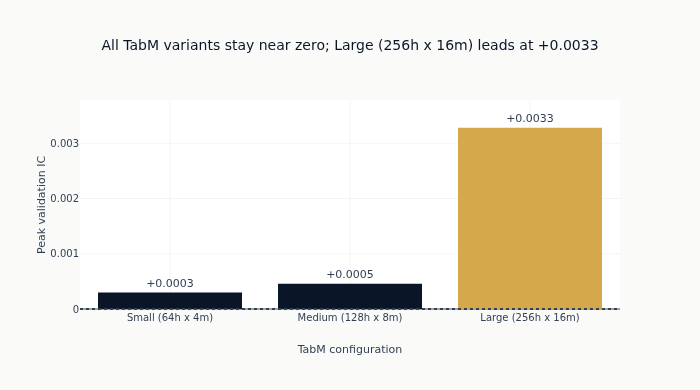

In [10]:
grid_results = result["grid_results"]
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
best_ic = result["best_ic"]

size_order = ["tabm_s", "tabm_m", "tabm_l"]
size_labels = {
    "tabm_s": "Small (64h x 4m)",
    "tabm_m": "Medium (128h x 8m)",
    "tabm_l": "Large (256h x 16m)",
}
grid_by_name = {row["config_name"]: row for row in grid_results}
ordered_grid = [grid_by_name[name] for name in size_order if name in grid_by_name]

fig = go.Figure(
    go.Bar(
        x=[size_labels.get(row["config_name"], row["config_name"]) for row in ordered_grid],
        y=[row["best_ic"] for row in ordered_grid],
        marker_color=[
            COLORS["amber"] if row["config_name"] == best_name else COLORS["blue"]
            for row in ordered_grid
        ],
        text=[f"{row['best_ic']:+.4f}" for row in ordered_grid],
        textposition="outside",
    )
)
fig.add_hline(y=0.0, line=dict(color=COLORS["neutral"], dash="dot"))
fig.update_layout(
    title_text=f"All TabM variants stay near zero; {size_labels[best_name]} leads at {best_ic:+.4f}",
    xaxis_title="TabM configuration",
    yaxis_title="Peak validation IC",
    height=390,
    showlegend=False,
)
fig.show()

## 5. Learning Curves

Validation IC at each 25-epoch checkpoint shows whether added optimization improves
the signal or merely moves a near-zero estimate around.

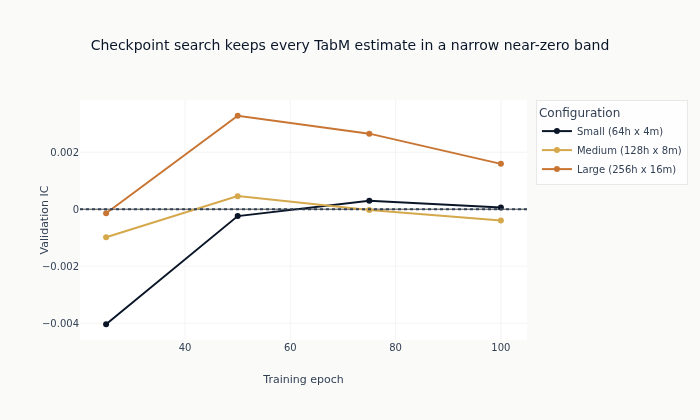

In [11]:
curves = result["all_learning_curves"]
if curves.height > 0:
    fig = go.Figure()
    curve_colors = {
        "tabm_s": COLORS["blue"],
        "tabm_m": COLORS["amber"],
        "tabm_l": COLORS["copper"],
    }
    for cfg_name in size_order:
        cfg_curve = curves.filter(pl.col("config") == cfg_name).sort("epoch")
        if cfg_curve.height:
            fig.add_trace(
                go.Scatter(
                    x=cfg_curve["epoch"],
                    y=cfg_curve["ic_mean"],
                    mode="lines+markers",
                    name=size_labels[cfg_name],
                    line=dict(color=curve_colors[cfg_name]),
                )
            )
    fig.add_hline(y=0.0, line=dict(color=COLORS["neutral"], dash="dot"))
    fig.update_layout(
        title_text="Checkpoint search keeps every TabM estimate in a narrow near-zero band",
        xaxis_title="Training epoch",
        yaxis_title="Validation IC",
        height=420,
        legend_title_text="Configuration",
    )
    fig.show()

## 6. Fold Metrics

Evaluate the selected model separately on each validation fold. This comparison
exposes temporal concentration that a single average can hide.

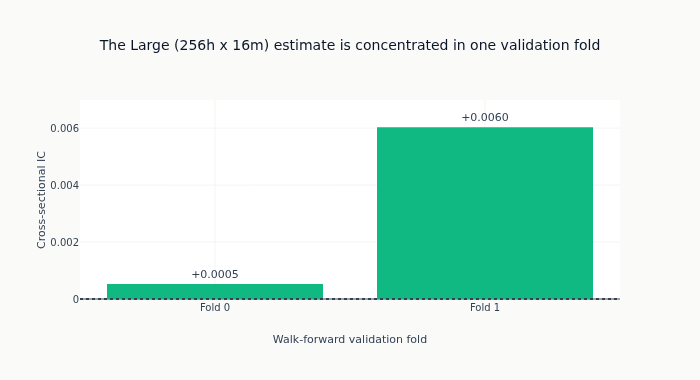

In [12]:
fold_metrics = result["fold_metrics"]
if fold_metrics.height > 0:
    mean_ic = fold_metrics["ic_mean"].mean()
    fig = go.Figure(
        go.Bar(
            x=[f"Fold {fold}" for fold in fold_metrics["fold_id"]],
            y=fold_metrics["ic_mean"],
            marker_color=[
                COLORS["positive"] if value >= 0 else COLORS["negative"]
                for value in fold_metrics["ic_mean"]
            ],
            text=[f"{value:+.4f}" for value in fold_metrics["ic_mean"]],
            textposition="outside",
        )
    )
    fig.add_hline(y=0.0, line=dict(color=COLORS["neutral"], dash="dot"))
    fig.update_layout(
        title_text=f"The {size_labels[best_name]} estimate is concentrated in one validation fold",
        xaxis_title="Walk-forward validation fold",
        yaxis_title="Cross-sectional IC",
        height=380,
        showlegend=False,
    )
    fig.show()

## 7. Registered Artifacts

`run_tabm_cv()` registers predictions and metrics during training. A cached run
reads those artifacts without changing the registry.

In [13]:
predictions = result["predictions"]
all_predictions = result["all_predictions"]

print(f"selected predictions: {predictions.height:,} rows")
print(f"all checkpoint predictions: {all_predictions.height:,} rows")
print(f"learning curve: {curves.height:,} config-checkpoint rows")
print(f"fold metrics: {fold_metrics.height} rows")

val_ic_mean = float(fold_metrics["ic_mean"].mean()) if fold_metrics.height > 0 else None

selected predictions: 142,941 rows
all checkpoint predictions: 1,715,292 rows
learning curve: 12 config-checkpoint rows
fold metrics: 2 rows


## 8. Run Summary

In [14]:
print(f"\n{'=' * 60}")
print(f"Tabular DL Grid Search: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"Features: {n_features}  |  Folds: {len(splits)}  |  Label: {label_col}")
print(f"Device: {device_str}  |  Epochs: {N_EPOCHS}")
print(f"Grid: {len(tabdl_configs)} configs ({', '.join(MODELS)})")
print(f"{'-' * 60}")
print(f"Best config: {best_name} @ epoch {best_epoch}")
print(f"Validation IC (cross-sectional): {best_ic:+.4f}")
if val_ic_mean is not None:
    print(f"Mean fold IC: {val_ic_mean:+.4f}")


Tabular DL Grid Search: sp500_options
Features: 52  |  Folds: 2  |  Label: ret_to_expiry
Device: cuda  |  Epochs: 100
Grid: 3 configs (tabm)
------------------------------------------------------------
Best config: tabm_l @ epoch 50
Validation IC (cross-sectional): +0.0033
Mean fold IC: +0.0033


## Key Takeaways

1. **TabM does not improve the primary-label signal.** All three ensembles remain
   close to zero on `ret_to_expiry`, well below the linear and GBM results on the
   same two validation folds.
2. **Capacity offers no robust rescue.** The leading configuration's advantage is
   concentrated in one fold and remains small.
3. **Checkpoint selection matters without creating evidence.** IC changes across
   the 25-epoch checkpoints, yet every path stays in a narrow band around zero.
4. **Prediction is not profitability.** Chapter 16 must still test the registered
   scores under the hold-to-expiry execution and cost model; near-zero IC provides
   no standalone economic case.

**Next**: Chapter 13 notebooks ([`09a_lstm`](09a_lstm.ipynb) and
[`09b_patchtst`](09b_patchtst.ipynb)) test whether the temporal evolution of IV
surfaces adds value beyond a flat feature snapshot.